In [1654]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [1655]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# np.set_printoptions(threshold=np.inf, linewidth=400, precision=2)

# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

In [1656]:
# 全局变量：保存上一帧数据，用于实时计算
prev_frame = None 

In [1657]:
# ===================== 数组自动网格输出（你要的格式） =====================
def auto_print(data, title):
    print(f"\n{'='*60}")
    print(f"📌 {title} | 形状 = {data.shape}")
    vec = data[0]
    n = len(vec)
    
    if n == 84:
        rows, cols = 7, 12
    elif n == 77:
        rows, cols = 7, 11
    elif n == 72:
        rows, cols = 6, 12
    elif n == 66:
        rows, cols = 6, 11
    else:
        print(vec)
        return
    
    print(f"✅ 输出格式：{rows}行 × {cols}列")
    print("-" * (cols * 7))
    grid = vec.reshape(rows, cols)
    for i in range(rows):
        print(f"行{i+1:2d} | " + " ".join(f"{v:6.1f}" for v in grid[i]))

# 打印全部行的矩阵
def print_full_matrix(data, title, rows, cols):
    print(f"\n{'='*60}")
    print(f"📌 {title} | 全部行 | {rows}×{cols}")
    for i in range(data.shape[0]):
        print(f"\n--- 第 {i+1} 行 ---")
        grid = data[i].reshape(rows, cols)
        for r in range(rows):
            print(f"行{r+1:2d} | " + " ".join(f"{v:6.1f}" for v in grid[r]))

In [1658]:
# 生成有效区间索引 [9,10,11,12,13,16,17,...,76] → 共50个
VALID_INDICES = []
start = 9
for i in range(10):
    base = start + i * 7
    VALID_INDICES.extend([base, base+1, base+2, base+3, base+4])

In [1659]:
# ===================== 基线扣除 + 有效区间内局部极大值 + 阈值>200 =====================
global first_frame
first_frame = None

def subtract_baseline(current_frame):
    global first_frame
    current_frame = np.array(current_frame, dtype=np.float32).flatten()
    cols = 7

    if first_frame is None:
        first_frame = current_frame.copy()

    # 基线扣除
    diff_frame = current_frame - first_frame
    abs_diff = np.abs(diff_frame)

    peak_cols = []

    # 遍历所有通道
    for col_idx in range(len(diff_frame)):  # 改用真实diff
        # ===================== 只判断：是否在有效区间 =====================
        is_valid = False
        start = 9
        for i in range(10):
            low = start + i * 7
            high = low + 4
            if low <= col_idx <= high:
                is_valid = True
                break
        
        # 不在有效区间直接跳过
        if not is_valid:
            continue

        # ===================== 局部极大值（真实值比较，不用abs）=====================
        current_val = diff_frame[col_idx]   # 👈 真实差值
        left_val  = diff_frame[col_idx - 1]
        right_val = diff_frame[col_idx + 1]
        up_val    = diff_frame[col_idx - cols]
        down_val  = diff_frame[col_idx + cols]

        # 👈 只比真实大小，不再比绝对值
        if (current_val > left_val and
            current_val > right_val and
            current_val > up_val and
            current_val > down_val and
            current_val > 500):  # 强度阈值保留

            peak_cols.append(col_idx)

    return diff_frame, peak_cols

In [1660]:
# ===================== 列差分（批量处理 + 输出固定50维） =====================
def compute_diff_adjacent(frame, peak_cols):
    frame = np.array(frame)
    output = np.zeros(50, dtype=np.float32)  # 保留 50 维
    
    # 批量处理所有峰值
    for col in peak_cols:
        diff = frame[col + 1] - frame[col - 1]
        idx = VALID_INDICES.index(col)  # 保留原来的索引映射
        output[idx] = diff  # 直接写入对应位置
    
    return output  # 返回 50 维向量

In [1661]:
# ===================== 行差分（批量处理 + 输出固定50维） =====================
def compute_diff_7step(frame, peak_cols):
    frame = np.array(frame)
    output = np.zeros(50, dtype=np.float32)  # 保留 50 维
    
    # 批量处理所有峰值
    for col in peak_cols:
        diff = frame[col + 7] - frame[col - 7]
        idx = VALID_INDICES.index(col)  # 保留原来逻辑
        output[idx] = diff
    
    return output  # 返回 50 维向量

In [1662]:
# -------------------- 4. 计算ADC角度 + 大小（强度） --------------------
def compute_gradient_angle(x_diff, y_diff):
    """
    输入：
      x_diff = 横向差分（右-左）
      y_diff = 纵向差分（上7-下7）
    输出：
      angle    : 0~360° 方向角
      magnitude: 梯度大小（强度）
    """
    epsilon = 1e-8
    
    # 1. 计算梯度大小（模长）= sqrt(x² + y²)
    magnitude = np.sqrt(x_diff**2 + y_diff**2)
    
    # 2. 计算方向角度
    angle = np.degrees(np.arctan2(-y_diff, -x_diff + epsilon))
    
    # 3. 转 0~360°
    if angle < 0:
        angle += 360
        
    return angle, magnitude

In [1663]:
# -------------------- 5. 计算Force角度 + 大小 --------------------
def compute_force_angle(Fx, Fy):
    import numpy as np
    epsilon = 1e-8
    
    # 1. 计算力的大小（模长 / 强度）
    magnitude = np.sqrt(Fx**2 + Fy**2)
    
    # 2. 计算角度（和你原来完全一样）
    angle = np.degrees(np.arctan2(Fy, Fx + epsilon))
    
    # 3. 转 0~360°
    angle = angle + 360 if angle < 0 else angle
    
    # 同时返回：角度 + 力的大小
    return angle, magnitude

In [1664]:
# -------------------- 4. 计算diff_adjacent_7step 先列再行二次差分 --------------------


In [1665]:
# ================================== 主程序（已适配新版函数） ==================================
import pandas as pd
import numpy as np

# 1. 读取数据
df = pd.read_csv('/home/qcy/Project/data/2.PZT_tangential/weight/test/data_5.csv')
data_original = df.iloc[:, 2:86].values

force_Fx = df.iloc[:, 86].values
force_Fy = df.iloc[:, 87].values

# 2. 初始化存储数组
data_diff = np.zeros_like(data_original)          # 基线扣除结果 (N,84)
diff_adjacent_list = []                           # 列差分结果 (N,72)
diff_adjacent7_list = []                          # 行差分结果 (N,50)
ADC_angle_list = []                               # 角度结果 (N,66) 
ADC_mag_list = []                                 # 新增：ADC大小
force_angle_list = []                             # Force角度结果 (N,1)
force_mag_list = []                               # 新增：Force大小
peak_cols_list = []                               # 所有峰值列号列表

# 3. 主循环
for i in range(data_original.shape[0]):
    # -------------------- 步骤1：基线扣除 + 获取所有峰值列 --------------------
    current_frame = data_original[i]
    diff_frame, peak_cols = subtract_baseline(current_frame)
    data_diff[i] = diff_frame
    peak_cols_list.append(peak_cols)  # 保存所有峰值列

    # -------------------- 步骤2：列差分（直接传 peak_cols） --------------------
    adj_rows = compute_diff_adjacent(diff_frame, peak_cols)
    
    # -------------------- 步骤3：行差分（直接传 peak_cols） --------------------
    adj_cols = compute_diff_7step(diff_frame, peak_cols)

    # 这两行保留
    diff_adjacent_list.append(adj_rows)
    diff_adjacent7_list.append(adj_cols)

    # -------------------- 步骤4：计算ADC角度 + 大小 --------------------
    angles = []
    mags = []  # 存储大小
    for xr, yr in zip(adj_rows, adj_cols):
        ang, mag = compute_gradient_angle(xr, yr)  # 新版返回两个值
        angles.append(ang)
        mags.append(mag)
    
    ADC_angle_list.append(angles)
    ADC_mag_list.append(mags)  # 保存大小

    # -------------------- 步骤5：计算Force角度 + 大小 --------------------   
    fx = force_Fx[i]
    fy = force_Fy[i]
    f_angle, f_mag = compute_force_angle(fx, fy)  # 新版返回两个值
    force_angle_list.append(f_angle)
    force_mag_list.append(f_mag)

# 转成numpy数组
diff_adjacent = np.array(diff_adjacent_list, dtype=object)
diff_adjacent7 = np.array(diff_adjacent7_list, dtype=object)
gradient_angle = np.array(ADC_angle_list, dtype=object)
gradient_mag = np.array(ADC_mag_list, dtype=object)  # 新增
force_angle = np.array(force_angle_list)
force_mag = np.array(force_mag_list)  # 新增
peak_cols_array = np.array(peak_cols_list, dtype=object)

In [1666]:
# ===================== 打印输出 =====================
print(f"\n✅ data_original shape: {data_original.shape}")
print_full_matrix(data_original, "data_original", 12, 7)


✅ data_original shape: (264, 84)

📌 data_original | 全部行 | 12×7

--- 第 1 行 ---
行 1 |    2.0    2.0    4.0    4.0    2.0    2.0    0.0
行 2 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行 3 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行 4 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行 5 |    2.0    2.0    4.0    4.0    2.0    2.0    2.0
行 6 |    2.0    4.0    2.0    4.0    4.0    2.0    2.0
行 7 |    2.0    4.0    4.0    2.0    4.0    2.0    2.0
行 8 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行 9 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行10 |    2.0    2.0    2.0    2.0    2.0    2.0    0.0
行11 |    2.0    4.0    4.0    2.0    2.0    4.0    2.0
行12 |    2.0    2.0    2.0    2.0    2.0    2.0    0.0

--- 第 2 行 ---
行 1 |    2.0    2.0    2.0    2.0    2.0    2.0    0.0
行 2 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行 3 |    2.0    2.0    4.0    2.0    2.0    2.0    2.0
行 4 |    2.0    2.0    2.0    2.0    2.0    2.0    2.0
行 5 |    2.0    2.0    2.0

In [1667]:
print(f"\n✅ data_diff 基线扣除 shape: {data_diff.shape}")
print_full_matrix(data_diff, "data_diff 基线扣除", 12, 7)


✅ data_diff 基线扣除 shape: (264, 84)

📌 data_diff 基线扣除 | 全部行 | 12×7

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行11 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行12 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0   -2.0   -2.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    2.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0   -2

In [1668]:
print(f"✅ diff_adjacent 列差分 shape: {diff_adjacent.shape}")
print_full_matrix(diff_adjacent, "diff_adjacent 列差分", 10, 5)

✅ diff_adjacent 列差分 shape: (264, 50)

📌 diff_adjacent 列差分 | 全部行 | 10×5

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 3 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    

In [1669]:
print(f"✅ diff_adjacent7 行差分 shape: {diff_adjacent7.shape}")
print_full_matrix(diff_adjacent7, "diff_adjacent7 行差分", 10, 5)

✅ diff_adjacent7 行差分 shape: (264, 50)

📌 diff_adjacent7 行差分 | 全部行 | 10×5

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 3 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0  

In [1670]:
print(f"✅ gradient_angle ADC角度 shape: {gradient_angle.shape}")
print_full_matrix(gradient_angle, "gradient_angle ADC角度", 10, 5)

✅ gradient_angle ADC角度 shape: (264, 50)

📌 gradient_angle ADC角度 | 全部行 | 10×5

--- 第 1 行 ---
行 1 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 2 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 3 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 4 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 5 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 6 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 7 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 8 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 9 |   -0.0   -0.0   -0.0   -0.0   -0.0
行10 |   -0.0   -0.0   -0.0   -0.0   -0.0

--- 第 2 行 ---
行 1 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 2 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 3 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 4 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 5 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 6 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 7 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 8 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 9 |   -0.0   -0.0   -0.0   -0.0   -0.0
行10 |   -0.0   -0.0   -0.0   -0.0   -0.0

--- 第 3 行 ---
行 1 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 2 |   -0.0   -0

In [1671]:
print(f"✅ force_angle Force角度 shape: {force_angle.shape}")
print_full_matrix(force_angle, "force_angle Force角度", 1, 1)

✅ force_angle Force角度 shape: (264,)

📌 force_angle Force角度 | 全部行 | 1×1

--- 第 1 行 ---
行 1 |   90.0

--- 第 2 行 ---
行 1 |   90.0

--- 第 3 行 ---
行 1 |   90.0

--- 第 4 行 ---
行 1 |   90.0

--- 第 5 行 ---
行 1 |   90.0

--- 第 6 行 ---
行 1 |   90.0

--- 第 7 行 ---
行 1 |  108.4

--- 第 8 行 ---
行 1 |   90.0

--- 第 9 行 ---
行 1 |  135.0

--- 第 10 行 ---
行 1 |  135.0

--- 第 11 行 ---
行 1 |  180.0

--- 第 12 行 ---
行 1 |   -0.0

--- 第 13 行 ---
行 1 |  104.0

--- 第 14 行 ---
行 1 |  116.6

--- 第 15 行 ---
行 1 |  153.4

--- 第 16 行 ---
行 1 |   90.0

--- 第 17 行 ---
行 1 |   90.0

--- 第 18 行 ---
行 1 |  135.0

--- 第 19 行 ---
行 1 |  135.0

--- 第 20 行 ---
行 1 |  123.7

--- 第 21 行 ---
行 1 |  123.7

--- 第 22 行 ---
行 1 |  135.0

--- 第 23 行 ---
行 1 |  116.6

--- 第 24 行 ---
行 1 |  153.4

--- 第 25 行 ---
行 1 |  135.0

--- 第 26 行 ---
行 1 |  135.0

--- 第 27 行 ---
行 1 |   90.0

--- 第 28 行 ---
行 1 |  153.4

--- 第 29 行 ---
行 1 |  116.6

--- 第 30 行 ---
行 1 |  108.4

--- 第 31 行 ---
行 1 |   90.0

--- 第 32 行 ---
行 1 |   90.0

--- 第 33 

In [1672]:
# ===================== 4. 拼接+保存（已适配 角度+大小） =====================
# 1. 处理 Force 角度 + 大小（转为2维）
force_angle = np.array(force_angle_list).reshape(-1, 1)
force_mag   = np.array(force_mag_list).reshape(-1, 1)

# 2. 处理 ADC 角度 + 大小（转为2维）
gradient_angle_2d = np.vstack([np.array(x).reshape(1, -1) for x in gradient_angle])
gradient_mag_2d   = np.vstack([np.array(x).reshape(1, -1) for x in gradient_mag])

# 3. 拼接所有数据：【ADC角度50】 + 【ADC大小50】 + 【力角度1】 + 【力大小1】
ADC_force_result = np.hstack([
    gradient_angle_2d,   # 50列：ADC角度
    gradient_mag_2d,     # 50列：ADC大小
    force_angle,         # 1列：Force角度
    force_mag            # 1列：Force大小
])

print(f"✅ 最终数据 shape: {ADC_force_result.shape}")  # 应该是 (N, 102)

# 4. 构造列名
columns = []
# 50个ADC角度
columns += [f"ADC_angle_{i+1}" for i in range(50)]
# 50个ADC大小
columns += [f"ADC_mag_{i+1}" for i in range(50)]
# 力角度 + 力大小
columns += ["Force_angle", "Force_mag"]

# 5. 生成DataFrame
df_result = pd.DataFrame(ADC_force_result, columns=columns)

# 控制台输出
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 9999)
print("✅ 带列名的完整二维表格：")
print(df_result)

# 6. 保存CSV
save_path = "/home/qcy/Project/data/2.PZT_tangential/weight/pre/ADC_Force_angle_result.csv"
df_result.to_csv(save_path, index=False, float_format="%.2f")

print(f"\n✅ 文件已保存到：\n{save_path}")

✅ 最终数据 shape: (264, 102)
✅ 带列名的完整二维表格：
    ADC_angle_1 ADC_angle_2 ADC_angle_3 ADC_angle_4 ADC_angle_5 ADC_angle_6 ADC_angle_7 ADC_angle_8 ADC_angle_9 ADC_angle_10 ADC_angle_11 ADC_angle_12 ADC_angle_13 ADC_angle_14 ADC_angle_15 ADC_angle_16 ADC_angle_17 ADC_angle_18 ADC_angle_19 ADC_angle_20 ADC_angle_21 ADC_angle_22 ADC_angle_23 ADC_angle_24 ADC_angle_25 ADC_angle_26 ADC_angle_27 ADC_angle_28 ADC_angle_29 ADC_angle_30 ADC_angle_31 ADC_angle_32 ADC_angle_33 ADC_angle_34 ADC_angle_35 ADC_angle_36 ADC_angle_37 ADC_angle_38 ADC_angle_39 ADC_angle_40 ADC_angle_41 ADC_angle_42 ADC_angle_43 ADC_angle_44 ADC_angle_45 ADC_angle_46 ADC_angle_47 ADC_angle_48 ADC_angle_49 ADC_angle_50 ADC_mag_1 ADC_mag_2 ADC_mag_3 ADC_mag_4 ADC_mag_5 ADC_mag_6 ADC_mag_7 ADC_mag_8 ADC_mag_9 ADC_mag_10 ADC_mag_11 ADC_mag_12 ADC_mag_13 ADC_mag_14 ADC_mag_15 ADC_mag_16 ADC_mag_17 ADC_mag_18 ADC_mag_19 ADC_mag_20 ADC_mag_21 ADC_mag_22 ADC_mag_23 ADC_mag_24 ADC_mag_25 ADC_mag_26 ADC_mag_27 ADC_mag_28 ADC_mag_29 ADC_ma

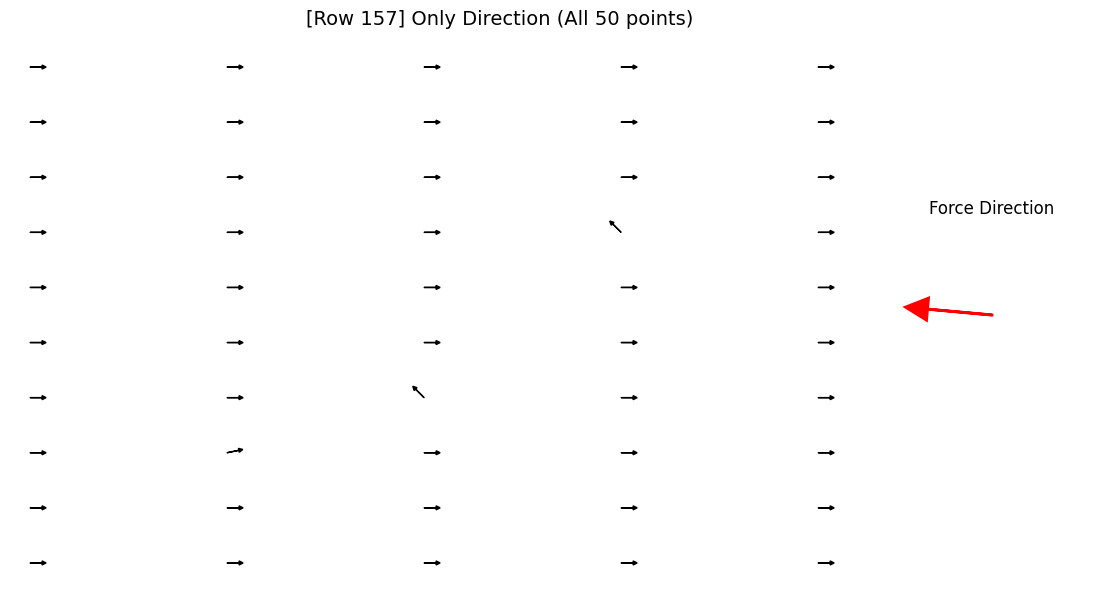

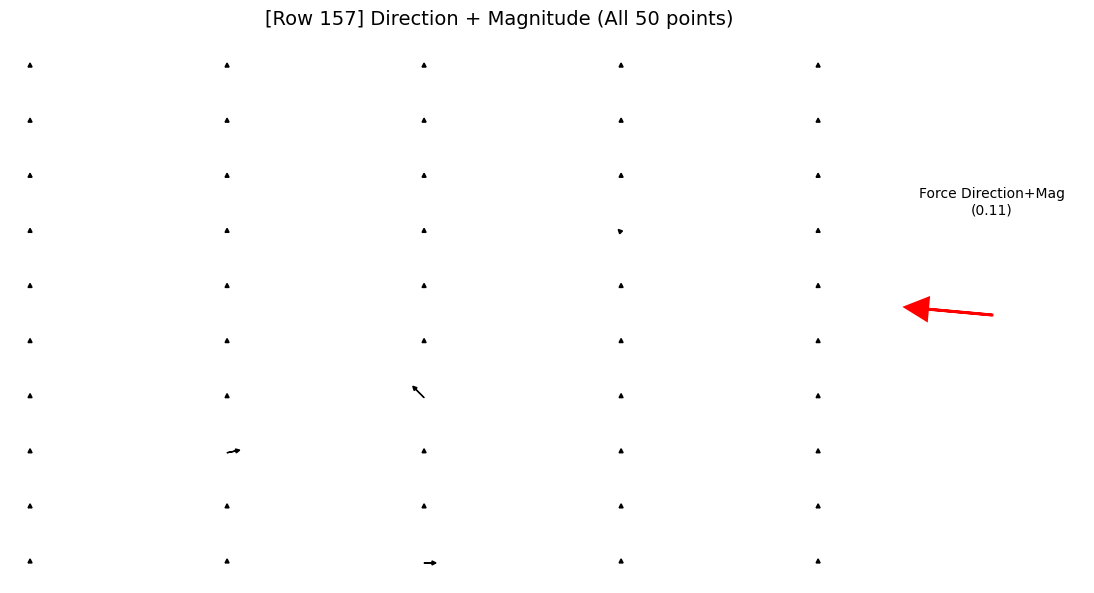

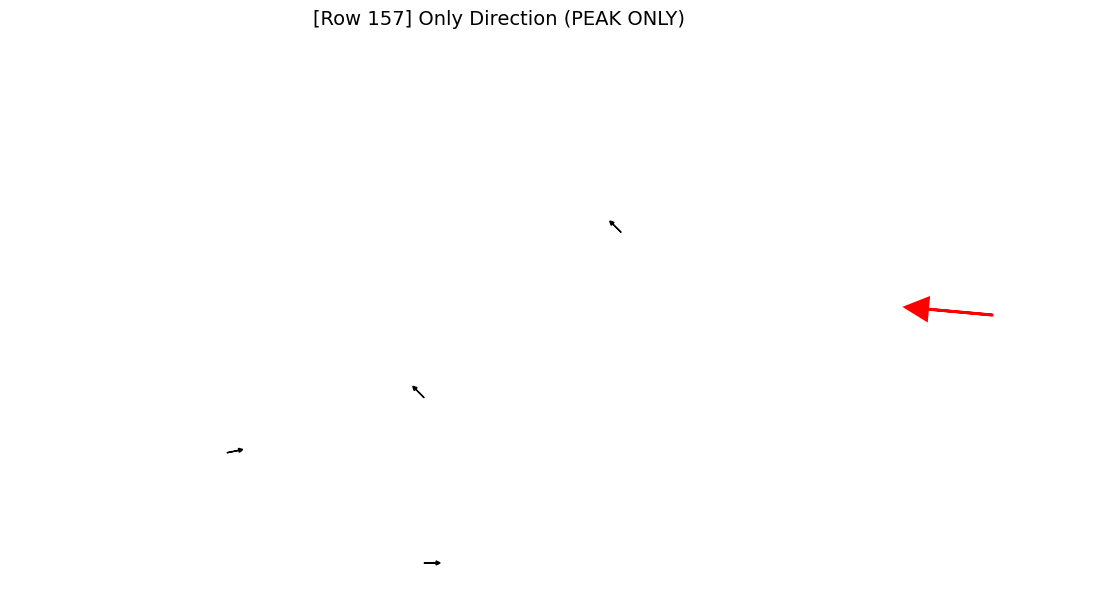

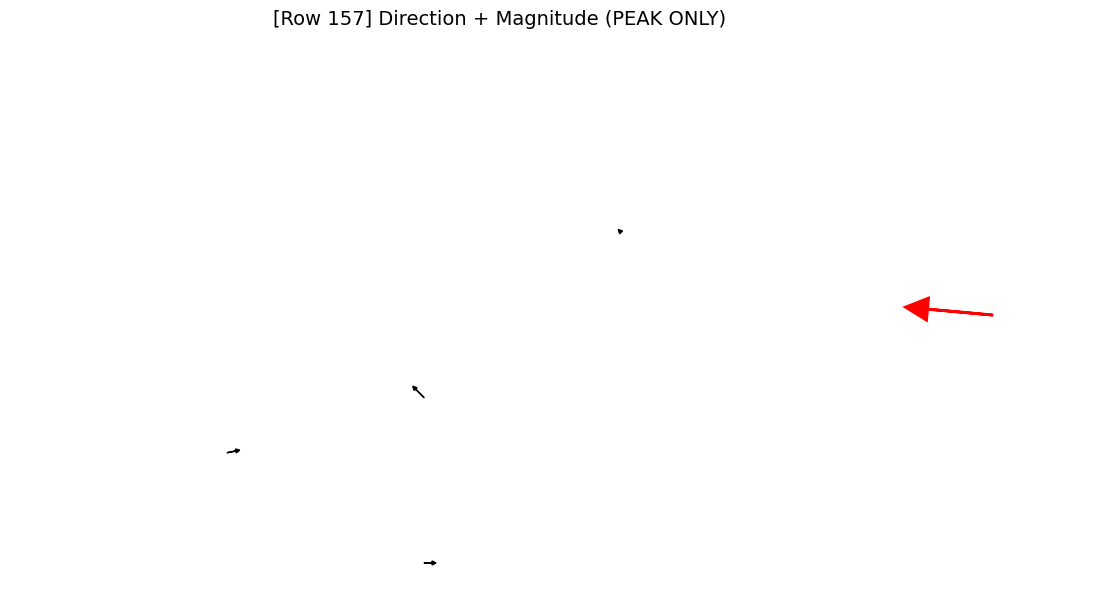

In [1673]:
# ===================== 图1：只显示方向（固定长度，全部50点） =====================
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# 关闭多余输出
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"

row_idx = 156

# 数据
adc_angles = ADC_force_result[row_idx, :50]
force_angle = ADC_force_result[row_idx, 100]

# 布局：左边10x5大，右边Force小
fig1, axes1 = plt.subplots(10, 6, figsize=(12, 6), gridspec_kw={'width_ratios': [1]*5 + [0.8]})

# 画ADC箭头（固定长度）
for idx in range(50):
    r = idx // 5
    c = idx % 5
    ax = axes1[r, c]
    theta = np.deg2rad(adc_angles[idx])
    ax.arrow(0.5, 0.5, 0.3*np.cos(theta), 0.3*np.sin(theta),
             head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_aspect('equal')
    ax.axis('off')

# 画Force箭头
ax_force1 = fig1.add_subplot(GridSpec(10,6, figure=fig1, width_ratios=[1]*5+[0.8])[:, 5])
theta_f = np.deg2rad(force_angle)
ax_force1.arrow(0.5, 0.5, 0.35*np.cos(theta_f), 0.35*np.sin(theta_f),
                head_width=0.12, head_length=0.12, fc='r', ec='r', linewidth=2)
ax_force1.set_xlim(0,1)
ax_force1.set_ylim(0,1)
ax_force1.set_aspect('equal')
ax_force1.axis('off')
ax_force1.set_title("Force Direction", fontsize=12)

# 隐藏多余的第6列
for r in range(10): axes1[r,5].remove()

fig1.suptitle(f"[Row {row_idx+1}] Only Direction (All 50 points)", fontsize=14)
plt.tight_layout()
plt.show()


# ===================== 图2：方向 + 大小（全部50点） =====================
fig2, axes2 = plt.subplots(10, 6, figsize=(12, 6), gridspec_kw={'width_ratios': [1]*5 + [0.8]})

# 读取大小数据
adc_mags = ADC_force_result[row_idx, 50:100]
force_mag = ADC_force_result[row_idx, 101]

# 画ADC箭头（带大小）
for idx in range(50):
    r = idx // 5
    c = idx % 5
    ax = axes2[r, c]
    theta = np.deg2rad(adc_angles[idx])
    mag = adc_mags[idx]
    arrow_len = 0.3 * mag / (adc_mags.max() + 1e-8) if adc_mags.max() > 1e-8 else 0.3
    ax.arrow(0.5, 0.5, arrow_len*np.cos(theta), arrow_len*np.sin(theta),
             head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_aspect('equal')
    ax.axis('off')

# 画Force箭头（带大小）
ax_force2 = fig2.add_subplot(GridSpec(10,6, figure=fig2, width_ratios=[1]*5+[0.8])[:, 5])
force_len = 0.35 * force_mag / (force_mag + 1e-8) if force_mag > 1e-8 else 0.35
ax_force2.arrow(0.5, 0.5, force_len*np.cos(theta_f), force_len*np.sin(theta_f),
                head_width=0.12, head_length=0.12, fc='r', ec='r', linewidth=2)
ax_force2.set_xlim(0,1)
ax_force2.set_ylim(0,1)
ax_force2.set_aspect('equal')
ax_force2.axis('off')
ax_force2.set_title(f"Force Direction+Mag\n({force_mag:.2f})", fontsize=10)

# 隐藏多余子图
for r in range(10): axes2[r,5].remove()

fig2.suptitle(f"[Row {row_idx+1}] Direction + Magnitude (All 50 points)", fontsize=14)
plt.tight_layout()
plt.show()


# ===================== 图3：【修复】只在VALID_INDICES峰值画方向 =====================
fig3, axes3 = plt.subplots(10, 6, figsize=(12, 6), gridspec_kw={'width_ratios': [1]*5 + [0.8]})

# 清空所有子图
for r in range(10):
    for c in range(5):
        axes3[r,c].set_xlim(0,1)
        axes3[r,c].set_ylim(0,1)
        axes3[r,c].set_aspect('equal')
        axes3[r,c].axis('off')

# 【正确】peak_cols → 转成 0~49 索引
peak_cols = peak_cols_array[row_idx]
for col in peak_cols:
    if col not in VALID_INDICES:
        continue
    idx = VALID_INDICES.index(col)  # 👈 关键：转成0~49
    r = idx // 5
    c = idx % 5
    theta = np.deg2rad(adc_angles[idx])
    axes3[r,c].arrow(0.5,0.5, 0.3*np.cos(theta), 0.3*np.sin(theta),
                     head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1)

# Force
ax_force3 = fig3.add_subplot(GridSpec(10,6, figure=fig3, width_ratios=[1]*5+[0.8])[:,5])
ax_force3.arrow(0.5,0.5, 0.35*np.cos(theta_f), 0.35*np.sin(theta_f),
                head_width=0.12, head_length=0.12, fc='r', ec='r', linewidth=2)
ax_force3.set_xlim(0,1); ax_force3.set_ylim(0,1)
ax_force3.set_aspect('equal'); ax_force3.axis('off')

for r in range(10): axes3[r,5].remove()
fig3.suptitle(f"[Row {row_idx+1}] Only Direction (PEAK ONLY)", fontsize=14)
plt.tight_layout()
plt.show()


# ===================== 图4：【修复】只在VALID_INDICES峰值画方向+大小 =====================
fig4, axes4 = plt.subplots(10, 6, figsize=(12, 6), gridspec_kw={'width_ratios': [1]*5 + [0.8]})

for r in range(10):
    for c in range(5):
        axes4[r,c].set_xlim(0,1); axes4[r,c].set_ylim(0,1)
        axes4[r,c].set_aspect('equal'); axes4[r,c].axis('off')

# 【正确】peak_cols → 转成 0~49 索引
for col in peak_cols:
    if col not in VALID_INDICES:
        continue
    idx = VALID_INDICES.index(col)
    r = idx // 5
    c = idx % 5
    theta = np.deg2rad(adc_angles[idx])
    mag = adc_mags[idx]
    arrow_len = 0.3 * mag / (adc_mags.max()+1e-8) if adc_mags.max()>1e-8 else 0.3
    axes4[r,c].arrow(0.5,0.5, arrow_len*np.cos(theta), arrow_len*np.sin(theta),
                     head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1)

# Force
ax_force4 = fig4.add_subplot(GridSpec(10,6, figure=fig4, width_ratios=[1]*5+[0.8])[:,5])
ax_force4.arrow(0.5,0.5, force_len*np.cos(theta_f), force_len*np.sin(theta_f),
                head_width=0.12, head_length=0.12, fc='r', ec='r', linewidth=2)
ax_force4.set_xlim(0,1); ax_force4.set_ylim(0,1)
ax_force4.set_aspect('equal'); ax_force4.axis('off')

for r in range(10): axes4[r,5].remove()
fig4.suptitle(f"[Row {row_idx+1}] Direction + Magnitude (PEAK ONLY)", fontsize=14)
plt.tight_layout()
plt.show()